# 📦 Bloque 1: Arquitectura de Figuras y Diseño Avanzado

📘** Explicación Teórica**


---


> La jerarquía en Matplotlib (Tema 6): Imaginen que Matplotlib funciona como un artista. La Figure (Figura) es el lienzo completo o el cuadro físico en la pared. Los Axes (Ejes) son las pinturas individuales o gráficos que se dibujan sobre ese lienzo. Una figura puede tener un solo gráfico o muchos subgráficos adentro.






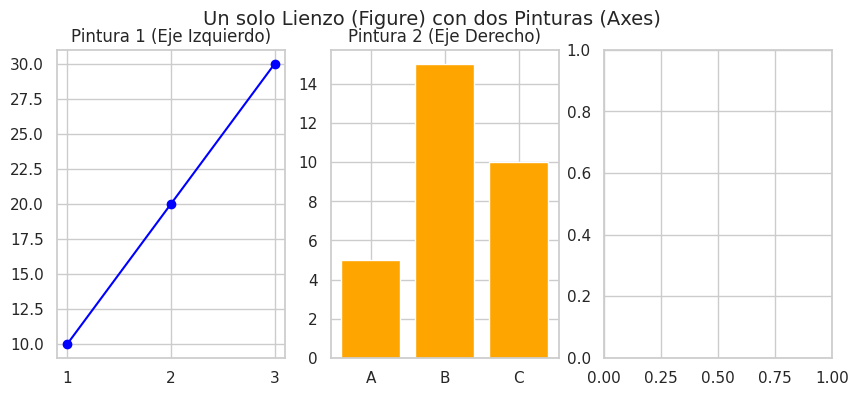

In [20]:
import matplotlib.pyplot as plt

# 1. Preparamos el lienzo global (Figure) con un tamaño de 10x4 pulgadas
# plt.subplots nos devuelve el lienzo (fig) y la lista de gráficos (axes)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4))

# 2. Como pedimos 1 fila y 2 columnas, 'axes' contiene dos elementos:
ax1 = axes[0] # Primera pintura (izquierda)
ax2 = axes[1] # Segunda pintura (derecha)

# 3. Dibujamos en la primera pintura usando el objeto 'ax1'
ax1.plot([1, 2, 3], [10, 20, 30], color="blue", marker="o")
ax1.set_title("Pintura 1 (Eje Izquierdo)")

# 4. Dibujamos en la segunda pintura usando el objeto 'ax2'
ax2.bar(["A", "B", "C"], [5, 15, 10], color="orange")
ax2.set_title("Pintura 2 (Eje Derecho)")

# 5. Añadimos un título general a todo el cuadro físico (Figure)
fig.suptitle("Un solo Lienzo (Figure) con dos Pinturas (Axes)", fontsize=14)
plt.show()


---
> Seaborn: Axes-level vs Figure-level (Tema 7):
Seaborn tiene dos formas de trabajar.

Las funciones Axes-level (como sns.scatterplot o sns.boxplot): se dibujan dentro de un lienzo (ax).

Las funciones Figure-level (como sns.displot) son "independientes": ellas mismas crean su propio lienzo y se adueñan de la pantalla.

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
--- 1. EJEMPLO AXES-LEVEL (Obediente) ---


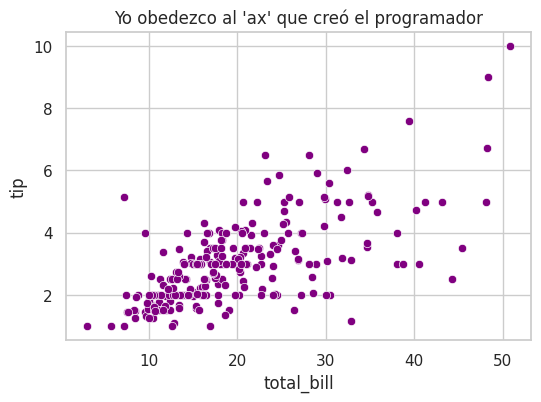


--- 2. EJEMPLO FIGURE-LEVEL (Independiente) ---


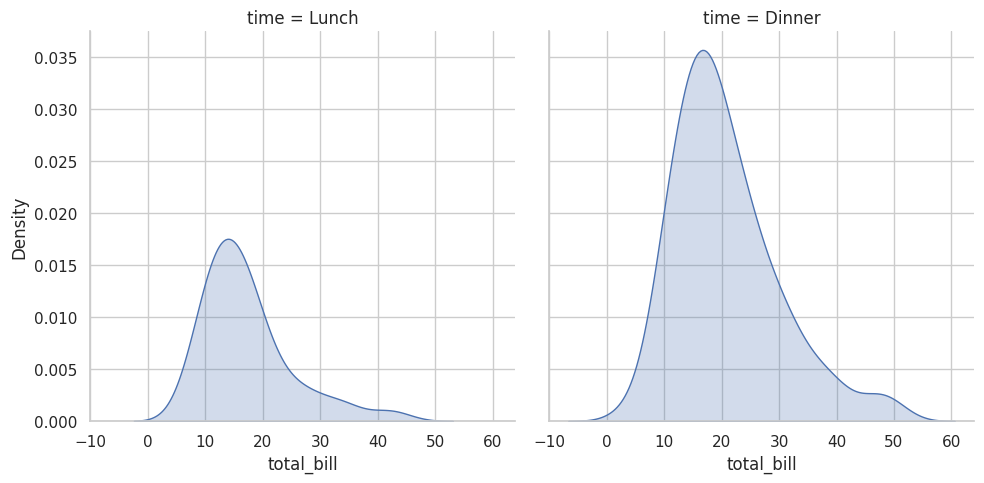

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
print(tips.head())

print("--- 1. EJEMPLO AXES-LEVEL (Obediente) ---")
# Creamos un ax manualmente con Matplotlib
fig, mi_eje = plt.subplots(figsize=(6, 4))
# Le ordenamos a Seaborn usar nuestro eje con 'ax=mi_eje'
sns.scatterplot(data=tips, x="total_bill", y="tip", ax=mi_eje, color="purple")
mi_eje.set_title("Yo obedezco al 'ax' que creó el programador")
plt.show()

print("\n--- 2. EJEMPLO FIGURE-LEVEL (Independiente) ---")
# No creamos ningún subplots previo. sns.displot se adueña del lienzo completo.
# Automáticamente sabe separar en columnas usando el parámetro 'col'
g = sns.displot(data=tips, x="total_bill", col="time", kind="kde", fill=True)

# 'g' no es un eje, es un FacetGrid (una figura completa administrada por Seaborn)
plt.show()

---
> GridSpec (Tema 10): Por defecto, los subplots dividen la pantalla en partes iguales (como una ventana cuadriculada). GridSpec es un módulo avanzado de Matplotlib que nos permite romper esa estructura para que un gráfico sea, por ejemplo, más alto o más ancho que otro, controlando la proporción del diseño visual (Tema 1).


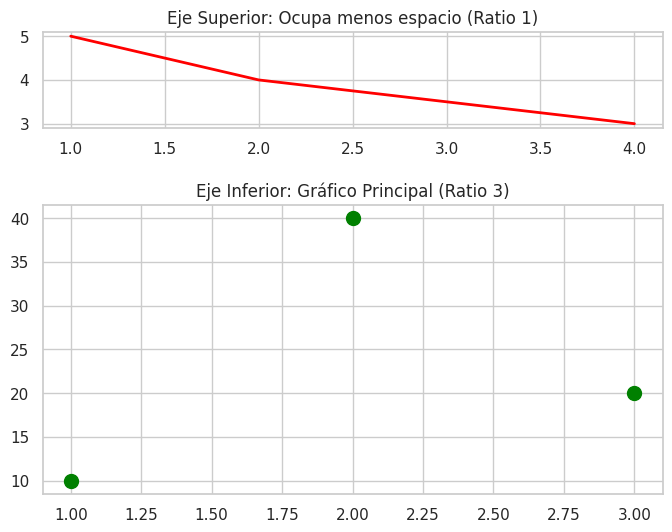

In [47]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 1. Creamos la figura contenedora
fig = plt.figure(figsize=(8, 6))

# 2. Definimos una cuadrícula invisible de 3 filas y 1 columna.
# 'height_ratios=[1, 3]' le dice a Matplotlib que la segunda fila debe ser 3 veces más alta que la primera.
# 'hspace=0.4' controla el espacio de separación vertical entre los gráficos.
gs = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[1, 3], hspace=0.4)

# 3. Asignamos los ejes correspondientes según la cuadrícula planeada
ax_superior = fig.add_subplot(gs[0]) # Se ubica en la posición 0 (fila de arriba)
ax_inferior = fig.add_subplot(gs[1]) # Se ubica en la posición 1 (fila de abajo)

# 4. Dibujamos en el eje superior (gráfico secundario o de resumen)
ax_superior.plot([1, 2, 4], [5, 4, 3], color="red", linewidth=2)
ax_superior.set_title("Eje Superior: Ocupa menos espacio (Ratio 1)")

# 5. Dibujamos en el eje inferior (gráfico principal detallado)
ax_inferior.scatter([1, 2, 3], [10, 40, 20], color="green", s=100)
ax_inferior.set_title("Eje Inferior: Gráfico Principal (Ratio 3)")

plt.show()

# 📦 Bloque 2: Series Temporales y Análisis Multivariado

📘 Explicación Teórica
---
> 📊 Tema 2: Series Temporales (Conversión a Datetime)

 Cuando trabajamos con fechas (años, meses, días), no basta con que el dato "parezca" una fecha en la tabla. Si Pandas lo lee como texto (objeto), al momento de graficarlo lo ordenará de forma alfabética (por ejemplo: Abril, Agosto, Diciembre, Enero...), rompiendo por completo la cronología del tiempo. Debemos forzar a Pandas a convertir esa columna en un tipo de dato especial llamado datetime.









💻 Ejemplo de Código Sencillo

Imaginemos que tenemos un registro de datos donde los años se cargaron desordenados o como texto:

--- 1. GRÁFICO INCORRECTO (Fechas como texto) ---


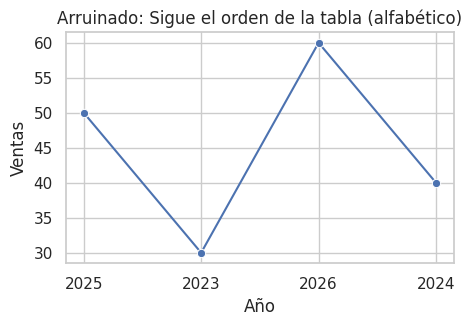


--- 2. GRÁFICO CORRECTO (Convertido a Datetime) ---


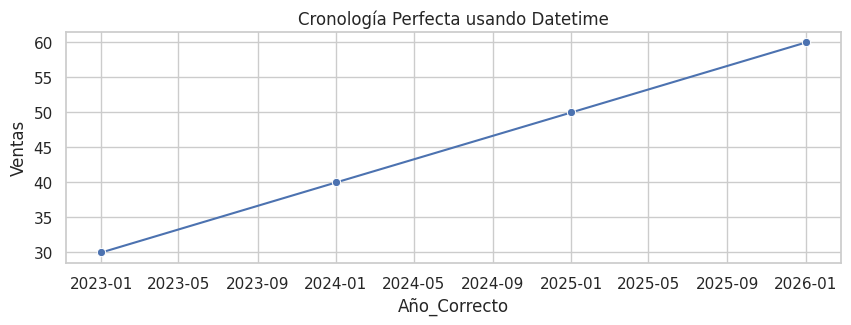

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos un DataFrame de ejemplo con los años desordenados y como texto (string)
data = {'Año': ['2025', '2023', '2026', '2024'], 'Ventas': [50, 30, 60, 40]}
df = pd.DataFrame(data)

print("--- 1. GRÁFICO INCORRECTO (Fechas como texto) ---")
plt.figure(figsize=(5, 3))
# Al ser texto, el eje X se graficará en el orden en que aparecen en la tabla, no cronológicamente
sns.lineplot(data=df, x="Año", y="Ventas", marker="o")
plt.title("Arruinado: Sigue el orden de la tabla (alfabético)")
plt.show()

print("\n--- 2. GRÁFICO CORRECTO (Convertido a Datetime) ---")
# Usamos pd.to_datetime para que Pandas entienda la línea de tiempo
df['Año_Correcto'] = pd.to_datetime(df['Año'], format='%Y')

plt.figure(figsize=(10, 3))
# Ahora, de forma automática, el eje X se ordena cronológicamente (2023 -> 2024 -> 2025 -> 2026)
sns.lineplot(data=df, x="Año_Correcto", y="Ventas", marker="o")
plt.title("Cronología Perfecta usando Datetime")
plt.show()

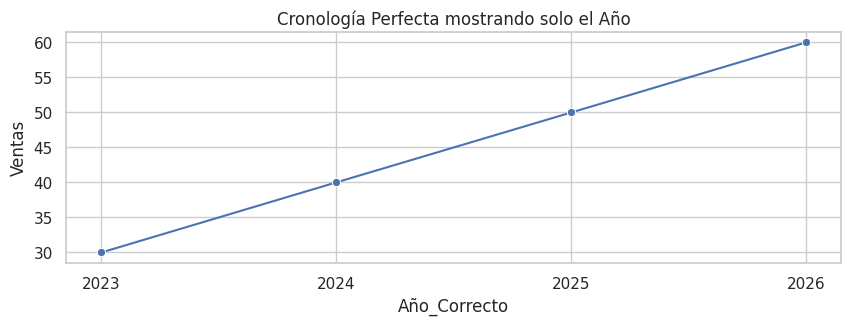

In [53]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns

# (Asumiendo que df ya tiene la columna 'Año_Correcto' como datetime)

plt.figure(figsize=(10, 3))
sns.lineplot(data=df, x="Año_Correcto", y="Ventas", marker="o")

# --- LA SOLUCIÓN AQUÍ ---
# 1. Obtenemos el eje actual del gráfico (ax)
ax = plt.gca()

# 2. Le decimos al eje X que formatee las fechas mostrando ÚNICAMENTE el año (%Y)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 3. (Opcional) Si tenés muchos años seguidos, podés decirle que ponga una marca por cada año
ax.xaxis.set_major_locator(mdates.YearLocator())
# -------------------------

plt.title("Cronología Perfecta mostrando solo el Año")
plt.show()

---
> 📈 Tema 4: Análisis Multivariado (Canales Estéticos)

Las pantallas de las computadoras y las hojas de papel son planas; solo tienen dos dimensiones ($X$ e $Y$). Si queremos analizar 3 o 4 variables al mismo tiempo, tenemos que mapear esas variables adicionales a canales estéticos o visuales: el color de los puntos (hue), la forma del marcador (style) o el tamaño del elemento (size).

💻 Ejemplo de Código Sencillo

Usando el dataset de propinas (tips), vamos a cruzar 4 variables en un solo gráfico plano:

Cuenta total (Eje X)

Propina (Eje Y)

¿Fumador o no? (Color / Hue)

Tamaño de la mesa (Tamaño / Size)

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


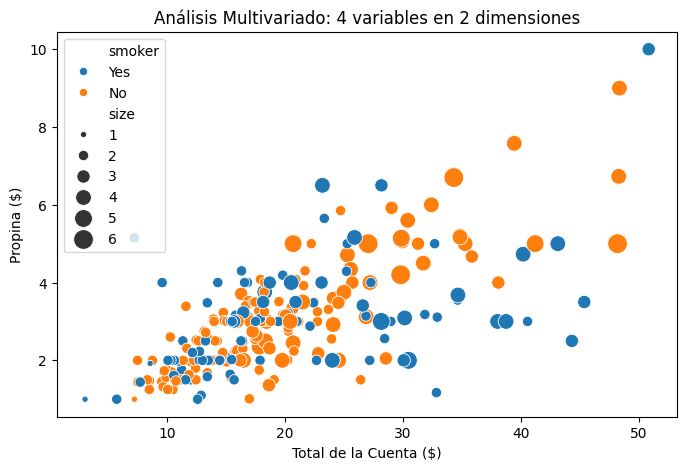

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
print(tips.head())

plt.figure(figsize=(8, 5))
# Cruzamos 4 variables usando canales estéticos
sns.scatterplot(
    data=tips,
    x="total_bill", # Variable 1 (Posición X)
    y="tip",        # Variable 2 (Posición Y)
    hue="smoker",   # Variable 3 (Canal de Color)
    size="size",    # Variable 4 (Canal de Tamaño)
    sizes=(20, 200) # Definimos el tamaño mínimo y máximo de los puntos
)

plt.title("Análisis Multivariado: 4 variables en 2 dimensiones")
plt.xlabel("Total de la Cuenta ($)")
plt.ylabel("Propina ($)")
plt.show()


---
> 🎨 Tema 5: Accesibilidad Cromática y Respaldo de Formas

 Cuando diseñamos una visualización, nunca debemos confiar toda la interpretación exclusivamente al color. Pensando en personas con daltonismo, o en el jefe que imprime los reportes de la oficina en una impresora blanco y negro, el color se puede perder o distorsionar. La regla de oro de la accesibilidad es respaldar el color con formas: si cambiás el color de una línea o punto, cambiá también su diseño (línea continua vs punteada, o círculo vs cuadrado).

💻 Ejemplo de Código Sencillo

Miremos cómo cambia la legibilidad de un gráfico al quitarle el color (simulando una impresión monocromática):

   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121
--- 1. DISEÑO CORREO (Con color y formas de respaldo) ---


/tmp/ipykernel_65003/2429257372.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



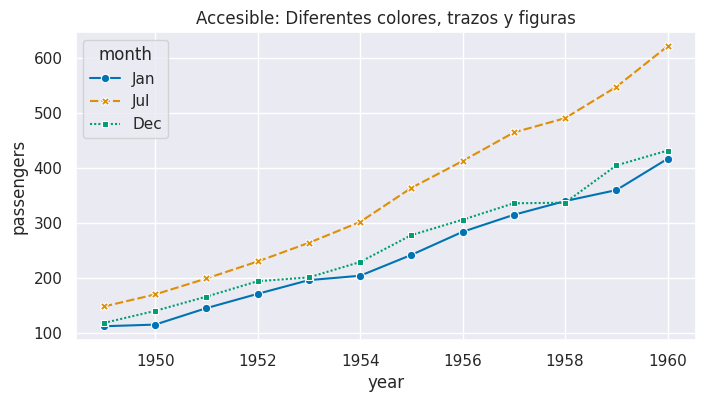

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos datos de vuelos
flights = sns.load_dataset("flights")
print(flights.head())
# Filtramos solo 3 meses para que el ejemplo sea simple
df_meses = flights[flights['month'].isin(['Jan', 'Jul', 'Dec'])]
df_meses['month'] = df_meses['month'].cat.remove_unused_categories()

print("--- 1. DISEÑO CORREO (Con color y formas de respaldo) ---")
plt.figure(figsize=(8, 4))
# 'palette="colorblind"' asegura colores aptos para daltonismo
# 'style' y 'markers' aseguran que si se imprime en blanco y negro se siga entendiendo
sns.lineplot(
    data=df_meses,
    x="year",
    y="passengers",
    hue="month",
    style="month",
    markers=True,
    palette="colorblind"
)
plt.title("Accesible: Diferentes colores, trazos y figuras")
plt.show()



# 📦 Bloque 3: Interactividad y Reportes de Alta Calidad


---
📊 Tema 9: Plotly Express (Interactividad nativa)

> Hasta ahora veníamos haciendo gráficos estáticos. Si les queríamos hacer zoom o ver un dato exacto, teníamos que volver a escribir código.

> Plotly Express cambia las reglas del juego: genera gráficos basados en tecnologías web (HTML y JavaScript).

> Esto significa que el usuario final puede interactuar con el gráfico directamente desde el navegador: hacer zoom en una zona, aislar una categoría haciendo clic en la leyenda, o ver etiquetas flotantes (tooltips) con los datos exactos al pasar el cursor.


💻 Ejemplo de Código Sencillo

Comparemos la experiencia interactiva frente a la estática usando el dataset de pingüinos:

In [65]:
import plotly.express as px
import seaborn as sns

penguins = sns.load_dataset("penguins")

# Con Plotly Express creamos un gráfico interactivo con una sola línea de código
# 'template="plotly_white"' asegura un diseño limpio y moderno
fig = px.scatter(
    penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    color="species",
    title="Gráfico Interactivo: Pasen el cursor por los puntos y pinchen la leyenda"
)


# .show() renderiza la interactividad en la celda de Jupyter o Colab
fig.show()

---
🖼️ Tema 11.1: Formatos de Exportación (Rasterizado vs Vectorial)

>  Cuando guardamos un gráfico para un informe, la extensión del archivo define su comportamiento.

> Formatos Rasterizados o Mapas de Bits (.png, .jpg): Están hechos de píxeles   (puntos de colores). Son perfectos para la web, PowerPoint o Word. Si los guardamos con baja calidad se van a ver borrosos, por lo que siempre debemos configurar una resolución alta (dpi=300).

>  Formatos Vectoriales (.pdf, .svg): No guardan píxeles, guardan las fórmulas matemáticas de dónde empieza y dónde termina cada línea. Esto significa que tienen resolución infinita: podés ampliarlos al tamaño de un cartel de publicidad en la vía pública y jamás se van a pixelar ni perder nitidez.



💻 Ejemplo de Código Sencillo

Vamos a guardar el mismo gráfico en ambos formatos para que vean cómo se hace desde el código:

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

penguins = sns.load_dataset("penguins")

sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g")
plt.title("Gráfico para Exportar")

# Opción A: Guardamos como PNG (píxeles) a alta resolución (300 DPI) para presentaciones
plt.savefig("grafico_alta_resolucion.png", dpi=300)

# Opción B: Guardamos como PDF (vectorial) con nitidez infinita para documentos impresos
plt.savefig("grafico_vectorial_infinito.pdf")

plt.close()
print("¡Archivos guardados en tu panel izquierdo de Colab/Jupyter!")

¡Archivos guardados en tu panel izquierdo de Colab/Jupyter!



---

📐 Tema 11.2: El parámetro bbox_inches='tight'


> Por defecto, Matplotlib calcula el tamaño de la imagen que va a guardar basándose en el tamaño del lienzo, pero a veces "se olvida" de medir el largo de los textos decorativos, como los nombres de los ejes o los títulos largos.

> El resultado es que cuando abrís la imagen guardada, el texto sale cortado por la mitad. Al agregar bbox_inches='tight', le ordenamos a Python que recalcule el encuadre rodeando absolutamente todo el contenido para que salga impecable.





💻 Ejemplo de Código Sencillo
Vamos a forzar un título largo y etiquetas grandes para ver la diferencia entre guardar con y sin este parámetro:

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

penguins = sns.load_dataset("penguins")

sns.histplot(data=penguins, x="flipper_length_mm", color="teal")

# Forzamos un título grande y etiquetas desplazadas que suelen cortarse
plt.title("Este es un título ridículamente largo que se suele cortar al exportar", fontsize=14, pad=20)
plt.xlabel("Largo de la Aleta (mm)", fontsize=14, labelpad=20)

# 1. INCORRECTO: Guardar de forma normal (Es muy probable que se corte el título o el eje X)
plt.savefig("grafico_mal_encuadrado.png")

# 2. CORRECTO: Usamos bbox_inches='tight' para asegurar que el encuadre sea perfecto
plt.savefig("grafico_perfecto.png", bbox_inches='tight')

plt.close()
print("Compará 'grafico_mal_encuadrado.png' contra 'grafico_perfecto.png' en tus archivos.")

Compará 'grafico_mal_encuadrado.png' contra 'grafico_perfecto.png' en tus archivos.




---



---


# 📝 Actividad Práctica Integradora: Análisis de Tráfico Aéreo


Objetivo: Aplicar las herramientas de visualización de Matplotlib, Seaborn y Plotly para analizar la eficiencia y evolución de los vuelos comerciales utilizando el dataset real de tráfico aéreo.

🛠️ Paso 1: Arquitectura y Distribución (Correspondiente al Bloque 1)


1. Cargá el archivo vuelos_asientos_pasajeros.csv usando Pandas.
2. Creá una estructura de Matplotlib basada en Figure y Axes.
3. Graficá un histograma (sns.histplot) para analizar la distribución de la cantidad de vuelos diarios (vuelos), configurando 30 barras (bins=30) y pintándolo de color azul acero (#4682B4).

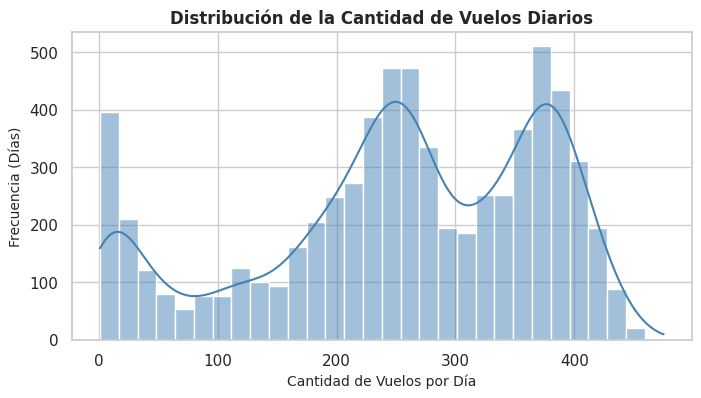

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Configuración de estilo básico de la sesión
sns.set_theme(style="whitegrid")

# 2. Carga del dataset local provisto
df_vuelos = pd.read_csv("vuelos_asientos_pasajeros.csv")

# 3. Creación explícita de la estructura jerárquica (Lienzo y Gráfico)
fig, ax = plt.subplots(figsize=(8, 4))

# 4. Inyección del gráfico de distribución de nivel de Eje (Axes-level)
sns.histplot(data=df_vuelos, x="vuelos", ax=ax, bins=30, color="#4682B4", kde=True)

# 5. Personalización estética básica
ax.set_title("Distribución de la Cantidad de Vuelos Diarios", fontsize=12, fontweight='bold')
ax.set_xlabel("Cantidad de Vuelos por Día", fontsize=10)
ax.set_ylabel("Frecuencia (Días)", fontsize=10)

plt.show()

📈 Paso 2: Análisis Temporal y Multivariado Inclusivo (Correspondiente al Bloque 2)


1. Convertí la columna indice_tiempo al formato correcto de tiempo (datetime).
2. Filtrá el DataFrame para quedarte únicamente con los datos correspondientes al año 2023.
3. Creá un gráfico de líneas donde se observe la evolución temporal de los pasajeros a lo largo del año.
4. Utilizá el canal estético del color y del estilo de línea para diferenciar la clasificacion_vuelo (Cabotaje vs Internacional). Aplicá una paleta apta para daltónicos (colorblind) y activá los marcadores para asegurar la accesibilidad.

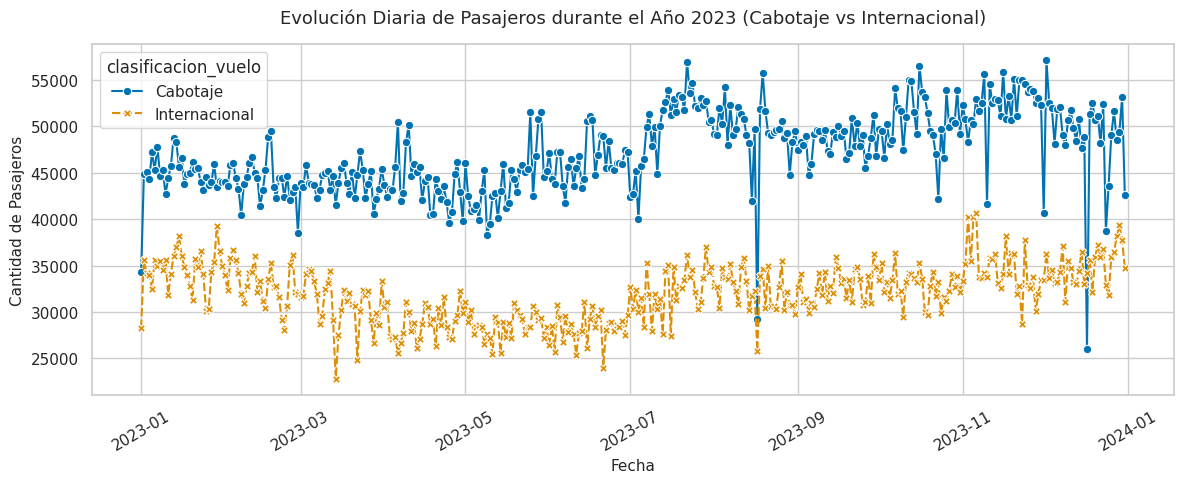

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carga del dataset (aseguramos tener los datos frescos)
df_vuelos = pd.read_csv("vuelos_asientos_pasajeros.csv")

# 2. TRANSFORMACIÓN: Convertimos la columna a tipo datetime (Tema 2)
df_vuelos['indice_tiempo'] = pd.to_datetime(df_vuelos['indice_tiempo'])

# 3. PREPARACIÓN: Filtramos mediante Pandas los registros del año 2023 (Tema 3)
df_2023 = df_vuelos[df_vuelos['indice_tiempo'].dt.year == 2023]

# 4. Creamos el contenedor del gráfico estático
plt.figure(figsize=(12, 5))

# 5. Gráfico multivariado con enfoque en accesibilidad cromática (Tema 4 y 5)
sns.lineplot(
    data=df_2023,
    x="indice_tiempo",
    y="pasajeros",
    hue="clasificacion_vuelo",
    style="clasificacion_vuelo", # Diferenciación de trazo para impresión B&N
    markers=True,                 # Marcadores geométricos inclusivos
    palette="colorblind"          # Paleta segura para daltonismo
)

# 6. Ajuste de etiquetas y presentación final
plt.title("Evolución Diaria de Pasajeros durante el Año 2023 (Cabotaje vs Internacional)", fontsize=13, pad=15)
plt.xlabel("Fecha", fontsize=11)
plt.ylabel("Cantidad de Pasajeros", fontsize=11)
plt.xticks(rotation=30) # Rotamos fechas para que no se superpongan
plt.tight_layout()
plt.show()

📊 Paso 3: Interactividad y Exportación Corporativa (Correspondiente al Bloque 3)

1. Creá un gráfico de dispersión interactivo con Plotly Express que compare la cantidad de asientos ofertados (Eje X) frente a los pasajeros reales transportados (Eje Y).
2. Configurá el color del punto según la clasificacion_vuelo y hacé que el tamaño del punto varíe de acuerdo a la cantidad de vuelos realizados ese día.
3. Escribí el bloque de código final en Matplotlib para exportar esta relación a una imagen .png de alta resolución (300 DPI) para un reporte de presentación, usando el encuadre perfecto.

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# 1. Carga de datos básica
df_vuelos = pd.read_csv("vuelos_asientos_pasajeros.csv")

# 2. Scatter Plot Interactivo con Plotly Express (Versión Simplificada)
fig_interactiva = px.scatter(
    df_vuelos,
    x="asientos",
    y="pasajeros",
    color="clasificacion_vuelo",
    size="vuelos",
    title="Análisis Interactivo: Asientos vs Pasajeros",
    template="plotly_white" # Mantiene el fondo limpio
)
fig_interactiva.show()

# 3. Exportación Estática de Alta Calidad con Seaborn (Versión Simplificada)
plt.figure(figsize=(7, 4.5))

# Seaborn ya sabe poner títulos a los ejes automáticamente usando los nombres de las columnas
sns.scatterplot(data=df_vuelos, x="asientos", y="pasajeros", hue="clasificacion_vuelo", size="vuelos")
plt.title("Ocupación de Vuelos: Asientos vs Pasajeros")

# Guardado profesional (El truco de alta resolución y encuadre sigue intacto)
plt.savefig("reporte_vuelos_300dpi.png", dpi=300, bbox_inches='tight')
plt.close()

print("¡Éxito! Gráfico estático guardado.")

¡Éxito! Gráfico estático guardado.
